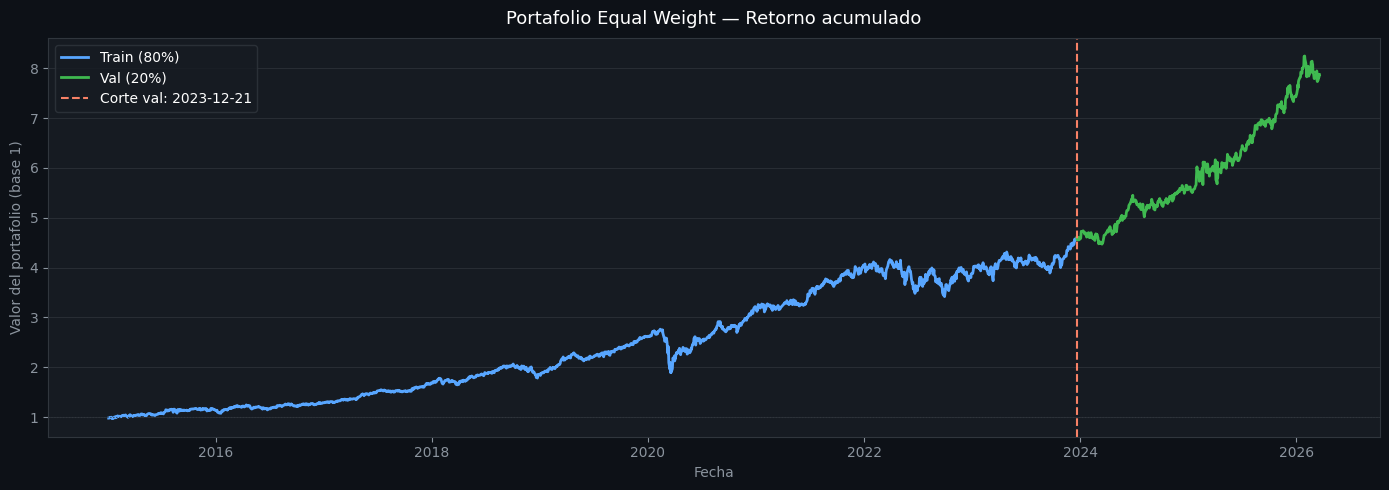

Sharpe anualizado train: 1.0830
Sharpe anualizado val:   1.5735
Retorno acumulado total: 7.8724
Retorno acumulado val:   1.7118


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Cargar datos ---
df = pd.read_csv('precios_cache.csv', index_col=0)
df.index = pd.to_datetime(df.index, utc=True).tz_convert(None)

# --- Retornos diarios ---
retornos = df.pct_change().dropna()

# --- Portafolio equal weight ---
n = df.shape[1]
w = np.ones(n) / n
r_p = retornos @ w
cum = (1 + r_p).cumprod()

# --- Línea de corte train/val (último 20%) ---
corte = int(len(cum) * 0.8)
fecha_corte = cum.index[corte]

# --- Gráfico ---
BG_FIG = '#0d1117'
BG_AX  = '#161b22'
GRID_C = '#30363d'
TXT    = 'white'
SUBT   = '#8b949e'

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG_FIG)
ax.set_facecolor(BG_AX)
ax.tick_params(colors=SUBT)
ax.spines[:].set_color(GRID_C)
ax.yaxis.grid(True, color=GRID_C, lw=0.5)
ax.xaxis.grid(False)

# Retorno acumulado
ax.plot(cum.index[:corte], cum.iloc[:corte],
        color='#58a6ff', lw=2, label='Train (80%)')
ax.plot(cum.index[corte:], cum.iloc[corte:],
        color='#3fb950', lw=2, label='Val (20%)')

# Línea vertical de corte
ax.axvline(fecha_corte, color='#f78166', lw=1.5,
           linestyle='--', label=f'Corte val: {fecha_corte.date()}')

ax.axhline(1, color=GRID_C, lw=0.8, linestyle=':')

ax.set_title('Portafolio Equal Weight — Retorno acumulado',
             color=TXT, fontsize=13, pad=10)
ax.set_xlabel('Fecha', color=SUBT, fontsize=10)
ax.set_ylabel('Valor del portafolio (base 1)', color=SUBT, fontsize=10)
ax.legend(facecolor=BG_AX, edgecolor=GRID_C, labelcolor=TXT, fontsize=10)

plt.tight_layout()
plt.savefig("Portfolio_Equal_Weight.png")
plt.show()

# --- Métricas ---
sharpe_train = r_p.iloc[:corte].mean() / r_p.iloc[:corte].std() * np.sqrt(252)
sharpe_val   = r_p.iloc[corte:].mean() / r_p.iloc[corte:].std() * np.sqrt(252)
print(f"Sharpe anualizado train: {sharpe_train:.4f}")
print(f"Sharpe anualizado val:   {sharpe_val:.4f}")
print(f"Retorno acumulado total: {cum.iloc[-1]:.4f}")
print(f"Retorno acumulado val:   {cum.iloc[-1]/cum.iloc[corte]:.4f}")